CUSTOMER CHURN PREDICTION
predciting whether a customer will leave a service or not using machine learning models and comparing their performances.


DATASET: Churn Modelling Dataset from Kaggle
Number of rows: 10000
Number of features: 14

In [42]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report,accuracy_score,roc_curve,auc, confusion_matrix



In [3]:
df= pd.read_csv(r"D:\DIGITIVITYTASK\Churn_Modelling.csv")
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [ ]:
print(df.info())
print(df.shape)


<bound method DataFrame.info of       RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
0             1    15634602   Hargrave          619    France  Female   42   
1             2    15647311       Hill          608     Spain  Female   41   
2             3    15619304       Onio          502    France  Female   42   
3             4    15701354       Boni          699    France  Female   39   
4             5    15737888   Mitchell          850     Spain  Female   43   
...         ...         ...        ...          ...       ...     ...  ...   
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumOfP

In [8]:
print(df.isnull().sum())
print(df.columns)

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [12]:
df.rename(columns={
    'EstimatedSalary':'Income',
    'NumOfProducts':'Purchases',
    'IsActiveMember':'Membership',
    'Exited':'Churn'
}, inplace=True)
print(df.columns)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'Purchases', 'HasCrCard',
       'Membership', 'Income', 'Churn'],
      dtype='object')


In [14]:
df= df[['Age','Balance','Purchases','Membership','Income','Churn']]
X=df.drop('Churn',axis=1)
y=df['Churn']
print(X.head())
print(y.head())

   Age    Balance  Purchases  Membership     Income
0   42       0.00          1           1  101348.88
1   41   83807.86          1           1  112542.58
2   42  159660.80          3           0  113931.57
3   39       0.00          2           0   93826.63
4   43  125510.82          1           1   79084.10
0    1
1    0
2    1
3    0
4    0
Name: Churn, dtype: int64


                 Age   Balance  Purchases  Membership    Income     Churn
Age         1.000000  0.028308  -0.030680    0.085472 -0.007201  0.285323
Balance     0.028308  1.000000  -0.304180   -0.010084  0.012797  0.118533
Purchases  -0.030680 -0.304180   1.000000    0.009612  0.014204 -0.047820
Membership  0.085472 -0.010084   0.009612    1.000000 -0.011421 -0.156128
Income     -0.007201  0.012797   0.014204   -0.011421  1.000000  0.012097
Churn       0.285323  0.118533  -0.047820   -0.156128  0.012097  1.000000


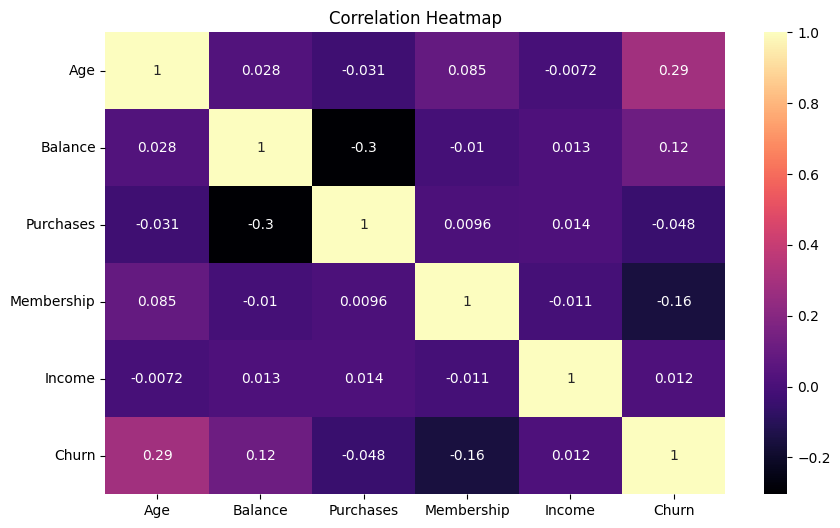

In [15]:
corr=df.corr()
print(corr)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='magma')
plt.title('Correlation Heatmap')
plt.show()

In [16]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True)*100)


Churn
0    7963
1    2037
Name: count, dtype: int64
Churn
0    79.63
1    20.37
Name: proportion, dtype: float64


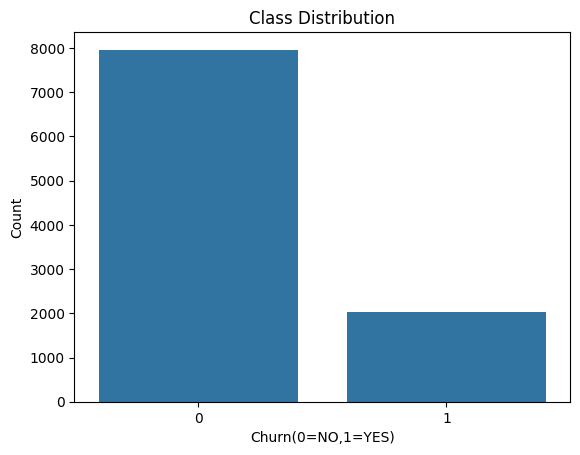

In [17]:
sns.countplot(x='Churn',data=df)
plt.title("Class Distribution")
plt.xlabel("Churn(0=NO,1=YES)")
plt.ylabel("Count")
plt.show()

There's a class imabalnce noticed in the dataset, with a higher proportion of non-churn customers. This can lead to biased predictions where the model favors the majority class, reducing the ability to correctly identity churn cases.

Feature Scaling to be done, to make sure that all variables contribute equally to the model training. Scaling prevents large-value features from domainating the model.

The dataset can be balanced to make sure the model doesnt make any biased predictions using oversampling techniques like SMOTE.

In [24]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train,y_test = train_test_split(X,y, random_state=42)
scaler = StandardScaler()

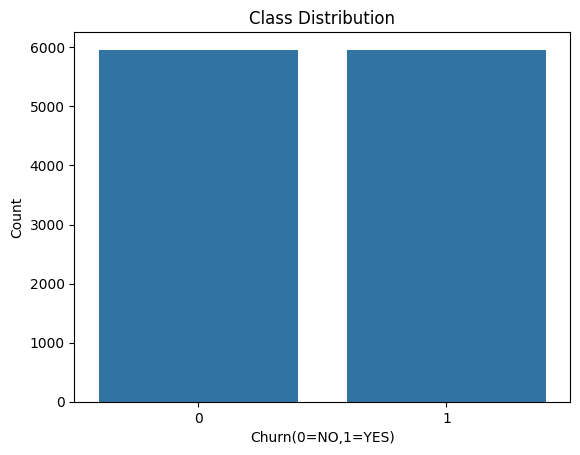

In [25]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
sm=SMOTE(random_state=42)
X_resampled,y_resampled = sm.fit_resample(X_train_scaled,y_train)

sns.countplot(x='y_resampled',data=pd.DataFrame({'y_resampled': y_resampled}))
plt.title("Class Distribution")
plt.xlabel("Churn(0=NO,1=YES)")
plt.ylabel("Count")
plt.show()

Without Smote

In [31]:
from sklearn.linear_model import LogisticRegression
lr =LogisticRegression()

lr.fit(X_train_scaled,y_train)
y_pred_lr= lr.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test,y_pred_lr))
print("Classification_Report:",classification_report(y_test,y_pred_lr))

Accuracy: 0.8064
Classification_Report:               precision    recall  f1-score   support

           0       0.82      0.97      0.89      2003
           1       0.55      0.15      0.23       497

    accuracy                           0.81      2500
   macro avg       0.68      0.56      0.56      2500
weighted avg       0.77      0.81      0.76      2500



With SMOTE

In [30]:
from sklearn.linear_model import LogisticRegression
lr =LogisticRegression()

lr.fit(X_resampled,y_resampled)
y_pred_lr= lr.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test,y_pred_lr))
print("Classification_Report:",classification_report(y_test,y_pred_lr))

Accuracy: 0.6976
Classification_Report:               precision    recall  f1-score   support

           0       0.90      0.70      0.79      2003
           1       0.36      0.70      0.48       497

    accuracy                           0.70      2500
   macro avg       0.63      0.70      0.63      2500
weighted avg       0.80      0.70      0.73      2500



[[1943   60]
 [ 424   73]]


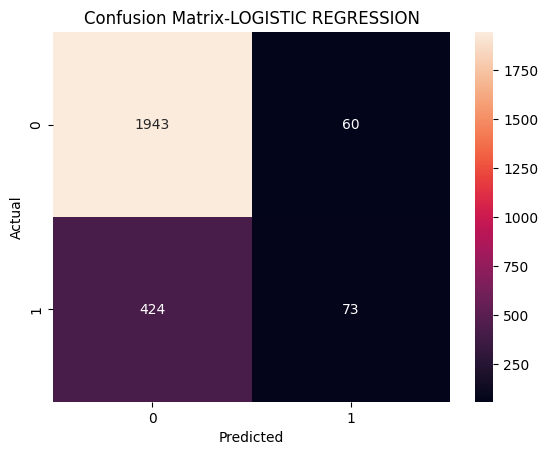

In [48]:
cm_lf = confusion_matrix(y_test,y_pred_lr)
print(cm_lf)
sns.heatmap(cm_lf,annot=True,fmt='d')
plt.title("Confusion Matrix-LOGISTIC REGRESSION")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


MODEL 2: RANDOM FOREST CLASSIFIER

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators= 100,random_state=42)
rf_clf.fit(X_resampled,y_resampled)


,n_estimators,100
,criterion,'gini'
,max_depth,100
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y_pred_rf=rf_clf.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test,y_pred_rf))

print("Classification Report:", classification_report(y_test,y_pred_rf))

Accuracy: 0.8244
Classification Report:               precision    recall  f1-score   support

           0       0.89      0.89      0.89      2003
           1       0.56      0.58      0.57       497

    accuracy                           0.82      2500
   macro avg       0.73      0.73      0.73      2500
weighted avg       0.83      0.82      0.83      2500



[[1775  228]
 [ 211  286]]


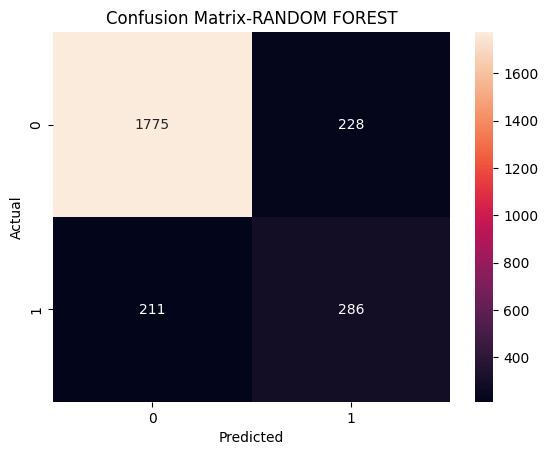

In [47]:
cm_rf = confusion_matrix(y_test,y_pred_rf)
print(cm_rf)

sns.heatmap(cm_rf, annot=True,fmt='d')
plt.title("Confusion Matrix-RANDOM FOREST")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

MODEL 3 - XGBoost

In [50]:
from xgboost import XGBClassifier
xgb_clf= XGBClassifier(use_label_encoder=False, eval_metric='logloss',random_state=42)

xgb_clf.fit(X_resampled,y_resampled)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
y_pred_xgb= xgb_clf.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test,y_pred_xgb))

print("Classification Report:", classification_report(y_test,y_pred_xgb))


Accuracy: 0.826
Classification Report:               precision    recall  f1-score   support

           0       0.89      0.89      0.89      2003
           1       0.56      0.57      0.56       497

    accuracy                           0.83      2500
   macro avg       0.73      0.73      0.73      2500
weighted avg       0.83      0.83      0.83      2500



[[1783  220]
 [ 215  282]]


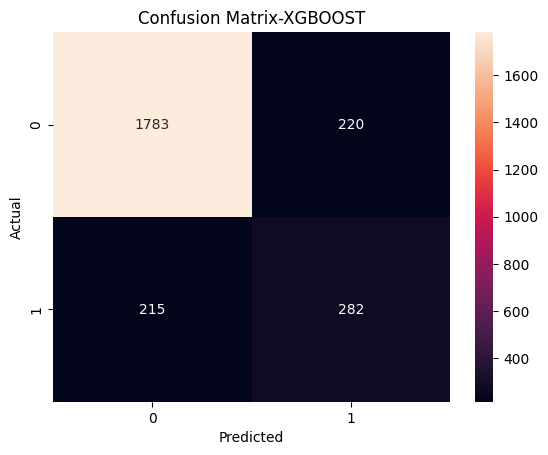

In [52]:
cm_xgb= confusion_matrix(y_test,y_pred_xgb)
print(cm_xgb)

sns.heatmap(cm_xgb, annot=True,fmt='d')
plt.title("Confusion Matrix-XGBOOST")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()  

COMPARISON

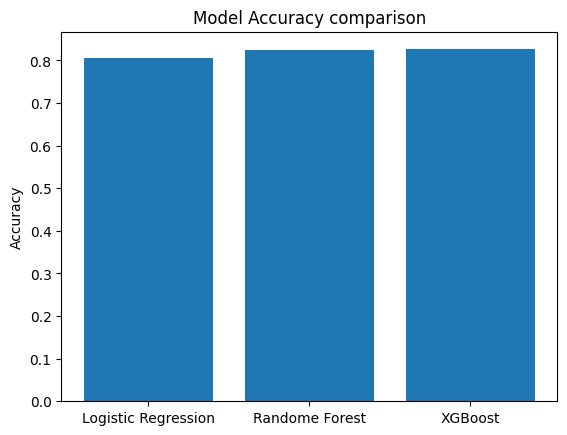

In [53]:
acc_lr=accuracy_score(y_test,y_pred_lr)
acc_rf=accuracy_score(y_test,y_pred_rf)
acc_xgb=accuracy_score(y_test,y_pred_xgb)

models=['Logistic Regression', 'Randome Forest', 'XGBoost']
accuracies=[acc_lr,acc_rf,acc_xgb]
plt.bar(models,accuracies)
plt.title("Model Accuracy comparison")
plt.ylabel("Accuracy")
plt.show()